# T4. Optimizacion de modelos - Dataset Iris


## 1. Importar librerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

sns.set_style("whitegrid")

## 2. Cargar y preparar los datos

El dataset Iris tiene 150 flores, 4 medidas (largo y ancho de sepalo y petalo)
y 3 especies con 50 ejemplos cada una. Se quita la columna `Id`, se divide en
entrenamiento y prueba y se estandarizan las variables.

In [2]:
df = pd.read_csv("Iris.csv").drop(columns=["Id"])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
print("Instancias:", df.shape[0], "| Caracteristicas:", df.shape[1] - 1)
print(df["Species"].value_counts().to_string())

Instancias: 150 | Caracteristicas: 4
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50


In [4]:
X = df.drop(columns=["Species"])
y = df["Species"]
etiquetas = sorted(y.unique())
etiquetas_corto = [s.replace("Iris-", "") for s in etiquetas]

# 70% entrenamiento y 30% prueba, manteniendo la proporcion de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Entrenamiento:", X_train.shape[0], "| Prueba:", X_test.shape[0])

Entrenamiento: 105 | Prueba: 45


## 3. Funciones para medir el desempeño

In [5]:
def matriz_confusion(y_real, y_pred, etiquetas):
    indice = {c: i for i, c in enumerate(etiquetas)}
    m = np.zeros((len(etiquetas), len(etiquetas)), dtype=int)
    for real, pred in zip(y_real, y_pred):
        m[indice[real], indice[pred]] += 1
    return m


def metricas_macro(cm):
    total = cm.sum()
    n = cm.shape[0]
    precision = sensibilidad = especificidad = f1 = 0.0
    for i in range(n):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = total - TP - FN - FP
        p = TP / (TP + FP) if (TP + FP) else 0
        r = TP / (TP + FN) if (TP + FN) else 0
        s = TN / (TN + FP) if (TN + FP) else 0
        precision += p
        sensibilidad += r
        especificidad += s
        f1 += 2 * p * r / (p + r) if (p + r) else 0
    return {
        "Accuracy": np.trace(cm) / total,
        "Precision": precision / n,
        "Sensibilidad": sensibilidad / n,
        "Especificidad": especificidad / n,
        "Macro F1": f1 / n,
    }


def graficar_matriz(cm, titulo):
    plt.figure(figsize=(4.3, 3.8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=etiquetas_corto, yticklabels=etiquetas_corto)
    plt.title(titulo)
    plt.xlabel("Prediccion")
    plt.ylabel("Valor real")
    plt.tight_layout()
    plt.show()

## 4. Modelos de linea base (valores por defecto)

Primero entrenamos los tres modelos tal como vienen por defecto. Estos seran el
punto de partida para la comparacion.

In [6]:
modelos_base = {
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Arbol": DecisionTreeClassifier(random_state=42),
}

base = {}
cm_base = {}
for nombre, modelo in modelos_base.items():
    modelo.fit(X_train, y_train)
    cm = matriz_confusion(y_test, modelo.predict(X_test), etiquetas)
    cm_base[nombre] = cm
    base[nombre] = metricas_macro(cm)
    print(nombre, {k: round(v, 4) for k, v in base[nombre].items()})

KNN {'Accuracy': np.float64(0.9111), 'Precision': np.float64(0.9298), 'Sensibilidad': np.float64(0.9111), 'Especificidad': np.float64(0.9556), 'Macro F1': np.float64(0.9095)}
SVM {'Accuracy': np.float64(0.9333), 'Precision': np.float64(0.9345), 'Sensibilidad': np.float64(0.9333), 'Especificidad': np.float64(0.9667), 'Macro F1': np.float64(0.9333)}
Arbol {'Accuracy': np.float64(0.9111), 'Precision': np.float64(0.9155), 'Sensibilidad': np.float64(0.9111), 'Especificidad': np.float64(0.9556), 'Macro F1': np.float64(0.9107)}


## 5. Optimizacion de hiperparametros

Optimizar es buscar la mejor combinacion de hiperparametros. Usamos `GridSearchCV`,
que prueba muchas combinaciones evaluando cada una con validacion cruzada de 5
particiones y se queda con la mejor.

- KNN: numero de vecinos, tipo de peso y forma de medir la distancia.
- SVM: kernel, parametro C y gamma.
- Arbol: criterio, profundidad maxima y minimos para dividir/hoja.

In [7]:
busqueda_knn = GridSearchCV(
    KNeighborsClassifier(),
    {"n_neighbors": list(range(1, 21)), "weights": ["uniform", "distance"], "p": [1, 2]},
    cv=5, scoring="accuracy", n_jobs=-1).fit(X_train, y_train)
print("Mejor KNN:", busqueda_knn.best_params_, "| CV:", round(busqueda_knn.best_score_, 4))

Mejor KNN: {'n_neighbors': 14, 'p': 2, 'weights': 'uniform'} | CV: 0.981


In [8]:
busqueda_svm = GridSearchCV(
    SVC(),
    [{"kernel": ["linear"], "C": [0.1, 1, 10, 100]},
     {"kernel": ["rbf"], "C": [0.1, 1, 10, 100], "gamma": ["scale", 0.01, 0.1, 1]},
     {"kernel": ["poly"], "C": [0.1, 1, 10], "degree": [2, 3], "gamma": ["scale"]}],
    cv=5, scoring="accuracy", n_jobs=-1).fit(X_train, y_train)
print("Mejor SVM:", busqueda_svm.best_params_, "| CV:", round(busqueda_svm.best_score_, 4))

Mejor SVM: {'C': 100, 'kernel': 'linear'} | CV: 0.981


In [9]:
busqueda_arbol = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {"criterion": ["gini", "entropy"], "max_depth": [2, 3, 4, 5, None],
     "min_samples_split": [2, 5, 10], "min_samples_leaf": [1, 2, 4]},
    cv=5, scoring="accuracy", n_jobs=-1).fit(X_train, y_train)
print("Mejor Arbol:", busqueda_arbol.best_params_, "| CV:", round(busqueda_arbol.best_score_, 4))

Mejor Arbol: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2} | CV: 0.9524


### Validacion cruzada: antes y despues

Comparamos el puntaje de validacion cruzada por defecto contra el optimizado
(es lo que la busqueda intenta mejorar).

In [10]:
for nombre, modelo, busqueda in [
    ("KNN", KNeighborsClassifier(), busqueda_knn),
    ("SVM", SVC(), busqueda_svm),
    ("Arbol", DecisionTreeClassifier(random_state=42), busqueda_arbol),
]:
    cv_base = cross_val_score(modelo, X_train, y_train, cv=5, scoring="accuracy").mean()
    print(f"{nombre:6} CV por defecto: {cv_base:.4f}  ->  optimizado: {busqueda.best_score_:.4f}")

KNN    CV por defecto: 0.9524  ->  optimizado: 0.9810
SVM    CV por defecto: 0.9714  ->  optimizado: 0.9810
Arbol  CV por defecto: 0.9429  ->  optimizado: 0.9524


## 6. Evaluacion de los modelos optimizados

In [11]:
optimizados = {
    "KNN": busqueda_knn.best_estimator_,
    "SVM": busqueda_svm.best_estimator_,
    "Arbol": busqueda_arbol.best_estimator_,
}

opt = {}
cm_opt = {}
for nombre, modelo in optimizados.items():
    cm = matriz_confusion(y_test, modelo.predict(X_test), etiquetas)
    cm_opt[nombre] = cm
    opt[nombre] = metricas_macro(cm)
    print(nombre, {k: round(v, 4) for k, v in opt[nombre].items()})

KNN {'Accuracy': np.float64(0.9556), 'Precision': np.float64(0.9608), 'Sensibilidad': np.float64(0.9556), 'Especificidad': np.float64(0.9778), 'Macro F1': np.float64(0.9554)}
SVM {'Accuracy': np.float64(0.9333), 'Precision': np.float64(0.9444), 'Sensibilidad': np.float64(0.9333), 'Especificidad': np.float64(0.9667), 'Macro F1': np.float64(0.9327)}
Arbol {'Accuracy': np.float64(0.9778), 'Precision': np.float64(0.9792), 'Sensibilidad': np.float64(0.9778), 'Especificidad': np.float64(0.9889), 'Macro F1': np.float64(0.9778)}


## 7. Comparacion: linea base vs optimizado

In [12]:
filas = []
for nombre in ["KNN", "SVM", "Arbol"]:
    filas.append({"Modelo": nombre + " base", **base[nombre]})
    filas.append({"Modelo": nombre + " optimizado", **opt[nombre]})
comparativa = pd.DataFrame(filas)
comparativa.round(4)

,Modelo,Accuracy,Precision,Sensibilidad,Especificidad,Macro F1
0,KNN base,0.9111,0.9298,0.9111,0.9556,0.9095
1,KNN optimizado,0.9556,0.9608,0.9556,0.9778,0.9554
2,SVM base,0.9333,0.9345,0.9333,0.9667,0.9333
3,SVM optimizado,0.9333,0.9444,0.9333,0.9667,0.9327
4,Arbol base,0.9111,0.9155,0.9111,0.9556,0.9107
5,Arbol optimizado,0.9778,0.9792,0.9778,0.9889,0.9778


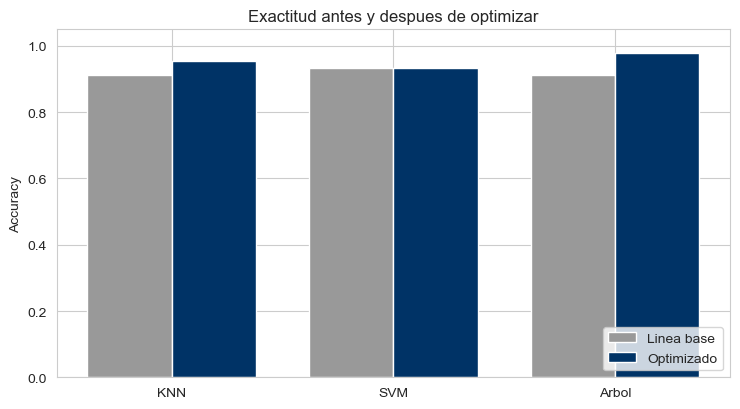

In [13]:
# Grafica de barras: accuracy base vs optimizado
modelos = ["KNN", "SVM", "Arbol"]
acc_base = [base[m]["Accuracy"] for m in modelos]
acc_opt = [opt[m]["Accuracy"] for m in modelos]
x = np.arange(len(modelos)); w = 0.38
plt.figure(figsize=(7.5, 4.2))
plt.bar(x - w/2, acc_base, w, label="Linea base", color="#999999")
plt.bar(x + w/2, acc_opt, w, label="Optimizado", color="#003366")
plt.xticks(x, modelos); plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Exactitud antes y despues de optimizar")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

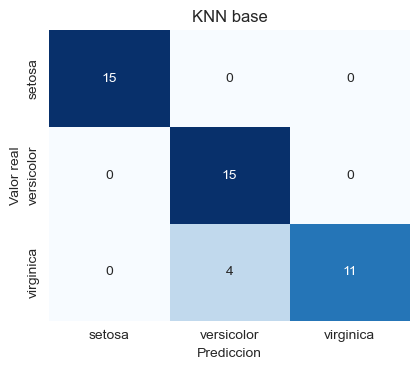

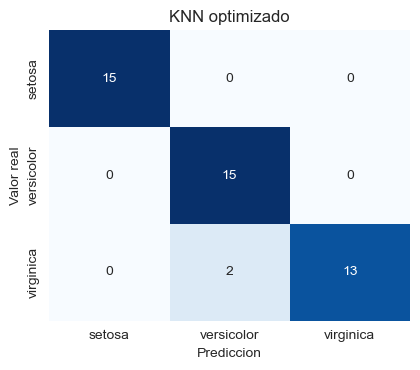

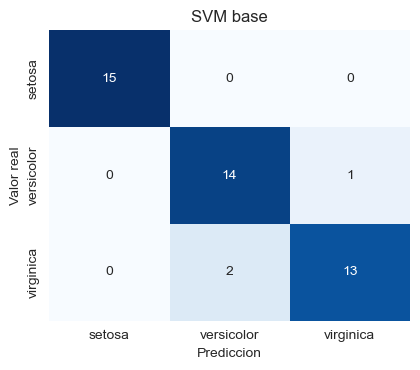

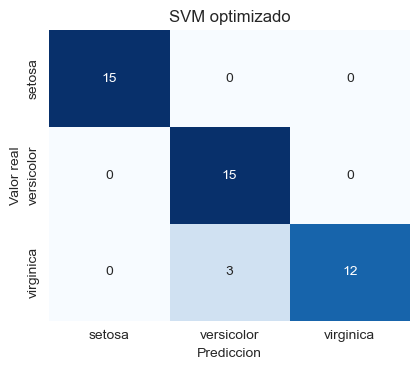

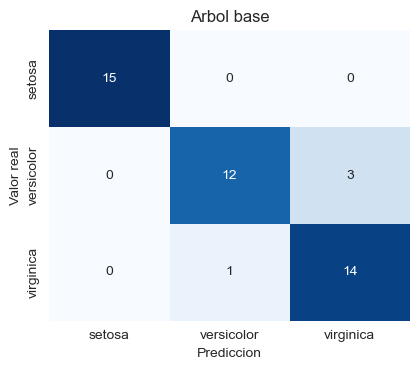

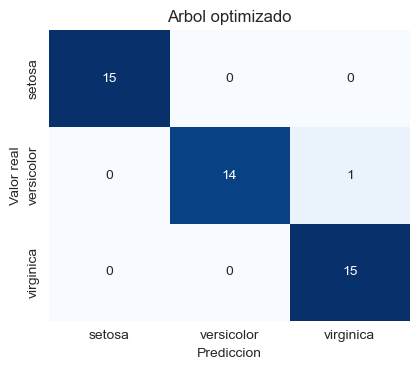

In [14]:
# Matrices de confusion: cada modelo, base vs optimizado
for nombre in ["KNN", "SVM", "Arbol"]:
    graficar_matriz(cm_base[nombre], f"{nombre} base")
    graficar_matriz(cm_opt[nombre], f"{nombre} optimizado")